# Create Images of Ship Sprites

In [2]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:60% !important; }</style>"))

Load in the sprite data

In [85]:
import re
from colors_map import *

sprites_files = ["uridium/src/ship_sprites.asm"]
sprites_data = {}
for sprites_file in sprites_files:
    input_file = open(sprites_file,'r')
    sprite_data = []
    for l in input_file.readlines():
        if "SPRITE" in l:
            if sprite_data:
                sprites_data[sprite_name] = sprite_data
            sprite_name = l[22:36].strip()
            sprite_data = []
            continue

        m = re.findall(r"[0-1]{24}",l)
        if not m:
            continue
        bits = m[0]
        sprite_line = []
        for i in range(0,23,2):
            bitpair = bits[i:i+2]
            sprite_line += [bitpair]
            sprite_line += [bitpair]
        sprite_data += [sprite_line]
    if sprite_data:
        sprites_data[sprite_name] = sprite_data

Function for actually drawing the sprite

In [86]:
from PIL import Image, ImageColor
SPRITE_COLS = 24
SPRITE_ROWS = 21
CELL_WIDTH = 40
CELL_HEIGHT = 40

def paintSprite(sprite, colors):
    multicol0, multicol1,color = colors
    colormap = {
        "01": multicol0,
        "10": color,
        "11": multicol1,
    }
    
    if sprite not in sprites_data:
        print(sprite)
        return
    
    image_width = SPRITE_COLS
    image_height = SPRITE_ROWS
    img = Image.new( 'RGBA', (image_width+1, image_height+1))
    pixels = img.load()

    bit_array = sprites_data[sprite]
    for y, l in enumerate(bit_array):
        for x,bit in enumerate(l):
            if bit == "00":
                continue
            pixel_color = ImageColor.getrgb(c64_to_rgb[colormap[bit]])
            pixels[x,y] = pixel_color
    return img


In [87]:
colors = (
    # cell color, text color
     "c64_yellow",
     "c64_white",
     "c64_black", 
)
sprite_images = []
sprite_frames = {}
for sprite_name in sprites_data:
    img = paintSprite(sprite_name, colors)
    sprite_images += [img]
    if sprite_name:
        sprite_frames[sprite_name] = img
        img.save(f"manta_spin_diagrams/{sprite_name}.png")
sprite_images[1]

In [214]:
animations = {}
animations["bankLeftTo90DegreesFacingRight"] = ["MANTA_RIGHT_13", "MANTA_RIGHT_14", "MANTA_RIGHT_15", "MANTA"] + ["MANTA1"]
animations["bankRightTo90DegreesFacingRight"] = ["MANTA_RIGHT_5", "MANTA_RIGHT_4", "MANTA_RIGHT_3", "MANTA_2"] + ["MANTA1"]
animations["flattenLeftFrom90DegreesFacingRight"] = ["MANTA1", "MANTA_2", "MANTA_RIGHT_3", "MANTA_RIGHT_4"]
"""
should be:
animations["flattenRightFrom90DegreesFacingRight"] = ["MANTA1", "MANTA_RIGHT_15", "MANTA_RIGHT_14", "MANTA_RIGHT_13"]
"""
animations["flattenRightFrom90DegreesFacingRight"] = ["MANTA1", "MANTA_2", "MANTA_RIGHT_3", "MANTA_RIGHT_4"]

animations["mantaFlipFromRightToLeft"] = [
    "MANTA_LEFT_9", "MANTA_LEFT_8", "MANTA_LEFT_7", "MANTA_LEFT_6", "MANTA_LEFT_5", "MANTA_LEFT_4",
    "MANTA_LEFT_3", "MANTA_LEFT_2", "MANTA_LEFT_1", "MANTA_FLIP_6", "MANTA_FLIP_5", "MANTA_FLIP_4", "MANTA_FLIP_3",
    "MANTA_FLIP_2", "MANTA_FLIP_1", "MANTA_FLIP_0" ] + ["MANTA1"]
animations["mantaRoll360DegreesRightFacingRight"] = [
    "MANTA1", "MANTA", "MANTA_RIGHT_15", "MANTA_RIGHT_14", "MANTA_RIGHT_13", "MANTA_RIGHT_12", "MANTA_RIGHT_11",
    "MANTA_RIGHT_10", "MANTA_RIGHT_9", "MANTA_RIGHT_8", "MANTA_RIGHT_7", "MANTA_RIGHT_6", "MANTA_RIGHT_5", "MANTA_RIGHT_4", "MANTA_RIGHT_3",
    "MANTA_2"] + ["MANTA1"]

animations["bankRightTo90DegreesFacingLeft"] = ["MANTA_LEFT_5", "MANTA_LEFT_6", "MANTA_LEFT_7", "MANTA_LEFT_8"] + ["MANTA_LEFT_9"]
animations["bankLeft90DegreesFacingLeft"] = ["MANTA_LEFT_13", "MANTA_LEFT_12", "MANTA_LEFT_11", "MANTA_LEFT_10"] + ["MANTA_LEFT_9"]
animations["flattenLeftFrom90DegreesFacingLeft"] = ["MANTA_LEFT_9", "MANTA_LEFT_8", "MANTA_LEFT_7", "MANTA_LEFT_6"] 
animations["flattenRightFrom90DegreesFacingLeft"] = ["MANTA_LEFT_9", "MANTA_LEFT_10", "MANTA_LEFT_11", "MANTA_LEFT_12"]

animations["mantaFlipFromLeftToRight"] = [
    "MANTA1", "MANTA", "MANTA_RIGHT_15", "MANTA_RIGHT_14", "MANTA_RIGHT_13",
    "MANTA_RIGHT_12", "MANTA_RIGHT_11", "MANTA_RIGHT_10", "MANTA_RIGHT_9", 
    "MANTA_FLIP_7", "MANTA_FLIP_8", "MANTA_FLIP_9", "MANTA_FLIP_10",
    "MANTA_FLIP_11", "MANTA_FLIP_12", "MANTA_FLIP_13"
] + ["MANTA_LEFT_9"]
animations["manta360RollLeft"] = [
    "MANTA_LEFT_9", "MANTA_LEFT_8", "MANTA_LEFT_7", "MANTA_LEFT_6", "MANTA_LEFT_5", "MANTA_LEFT_4", "MANTA_LEFT_3",
    "MANTA_LEFT_2", "MANTA_LEFT_1", "MANTA_LEFT_0", "MANTA_LEFT_15", "MANTA_LEFT_14", "MANTA_LEFT_13", "MANTA_LEFT_12", "MANTA_LEFT_11",
    "MANTA_LEFT_10"] + ["MANTA_LEFT_9"]



## A graphic showing the spin animation

In [88]:
def animateManta(animation):
    master_width = ((SPRITE_COLS + 7) * 16)
    master_height = SPRITE_ROWS + 10
    master_img = Image.new( 'RGBA', (master_width, master_height))
    x_offset = 5
    for sprite_name in reversed(animations[animation]): # The sprite animation starts at the end of the list.
        img = sprite_frames[sprite_name]
        master_img.paste(img, (x_offset,5))
        x_offset += SPRITE_COLS + 5
    master_img = master_img.resize((master_img.width * 10, master_img.height * 10), Image.NEAREST)
    return master_img

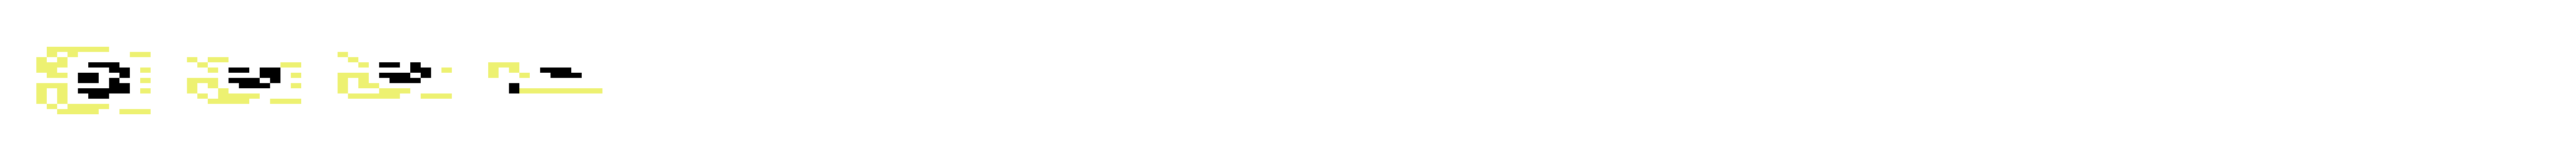

In [196]:
animateManta("bankLeftTo90DegreesFacingRight")

## Display the animation  with a fade-out effect

In [273]:
!mkdir -p manta_flip

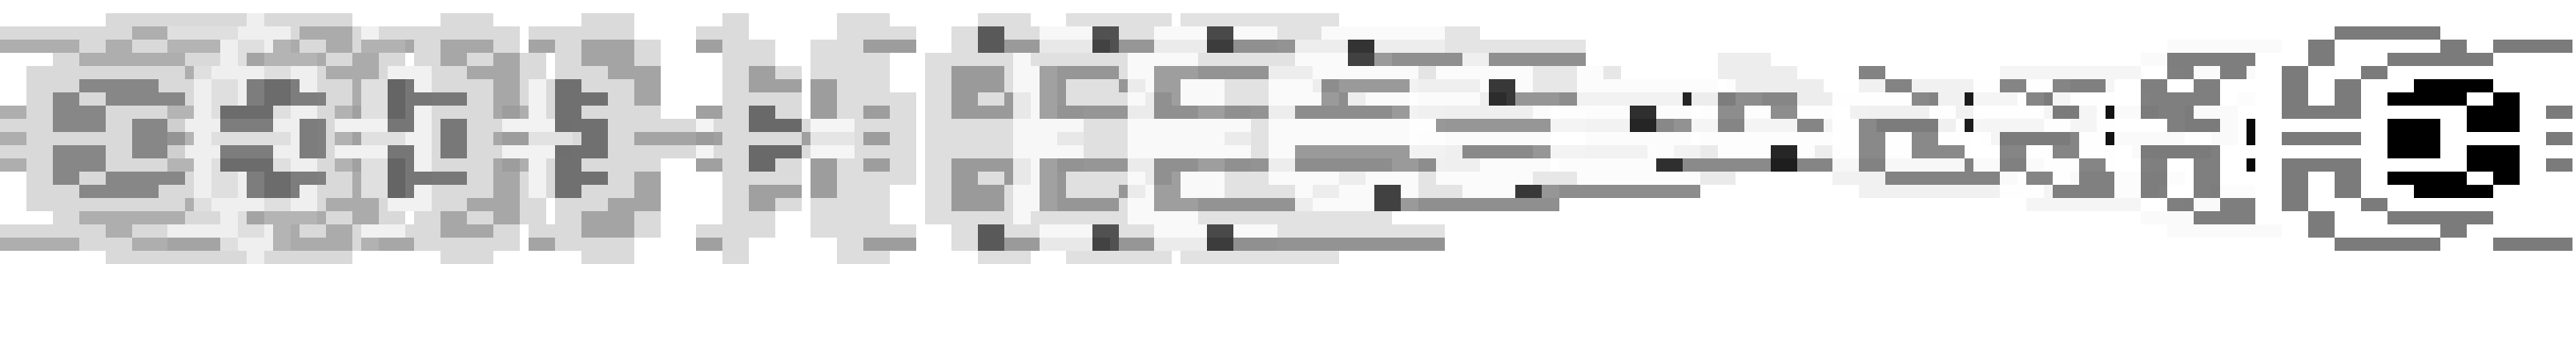

In [300]:
def animateMantaWithTransparency(level=1, animation="bankLeftTo90DegreesFacingRight", offset=160):
    frames = animations[animation]
    frames_with_alpha = reversed(list(zip(frames,range(255,0,-5))))
    
    img = Image.new('RGBA', (len(frames) * (offset + 12), 400))
    x,y = 0,0
    for sprite_name,alpha in frames_with_alpha:
        manta = Image.open(f"manta_sprites/{level}_{sprite_name}.png")
        manta = resize(manta, FACTOR)

        manta2 = manta.copy()
        manta2.putalpha(alpha)
        manta.paste(manta2, manta)
        
        img.paste(manta, (x,y),mask=manta)
        x+= offset
    return img

img = animateMantaWithTransparency(level=6, animation="mantaFlipFromLeftToRight")
img.save("manta_flip/manta_flip.png")
img

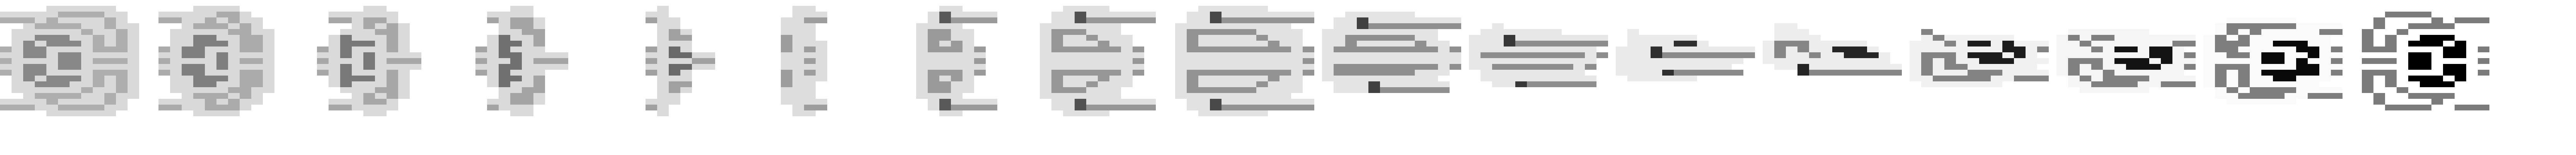

In [301]:
img = animateMantaWithTransparency(level=6, animation="mantaFlipFromLeftToRight",offset=380)
img.save("manta_flip/manta_flip_wide.png")
img

## Split the Animation

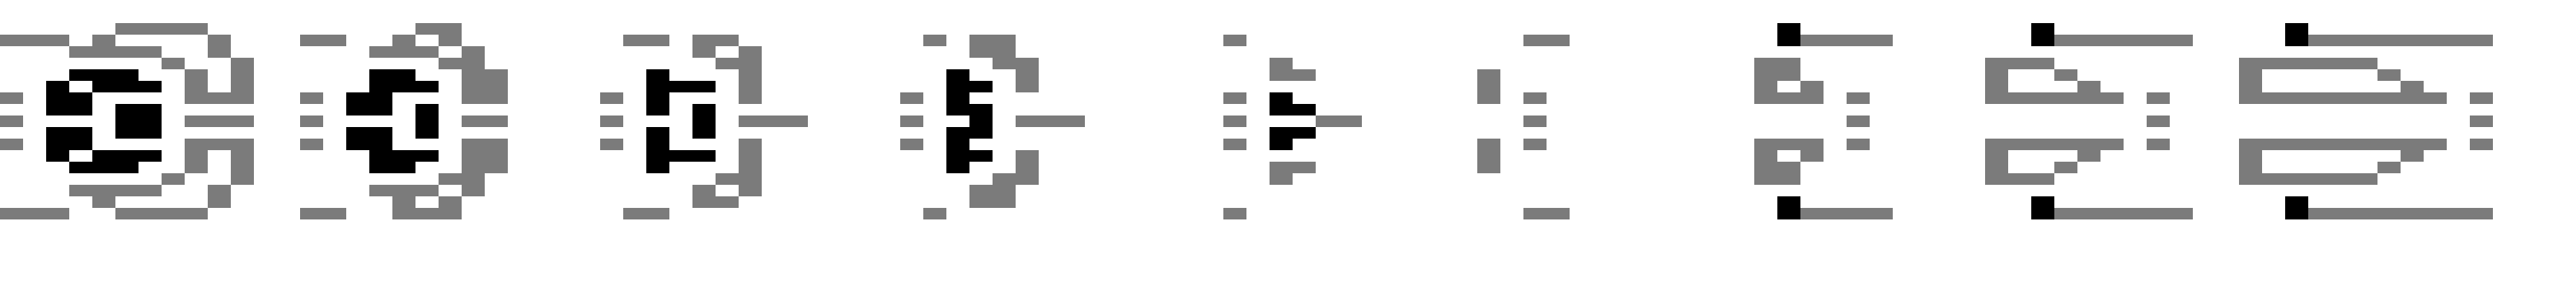

In [311]:
def animateFrames(frames, level=1, offset=160):
    img = Image.new('RGBA', (len(frames) * (offset + 12), 400))
    x,y = 0,0
    for sprite_name in frames:
        manta = Image.open(f"manta_sprites/{level}_{sprite_name}.png")
        manta = resize(manta, FACTOR)
        img.paste(manta, (x,y),mask=manta)
        x+= offset
    return img

frames = list(reversed(animations["mantaFlipFromLeftToRight"]))[:9]
img = animateFrames(frames, level=6, offset=360)
img.save("manta_flip/manta_flip_1.png")
img

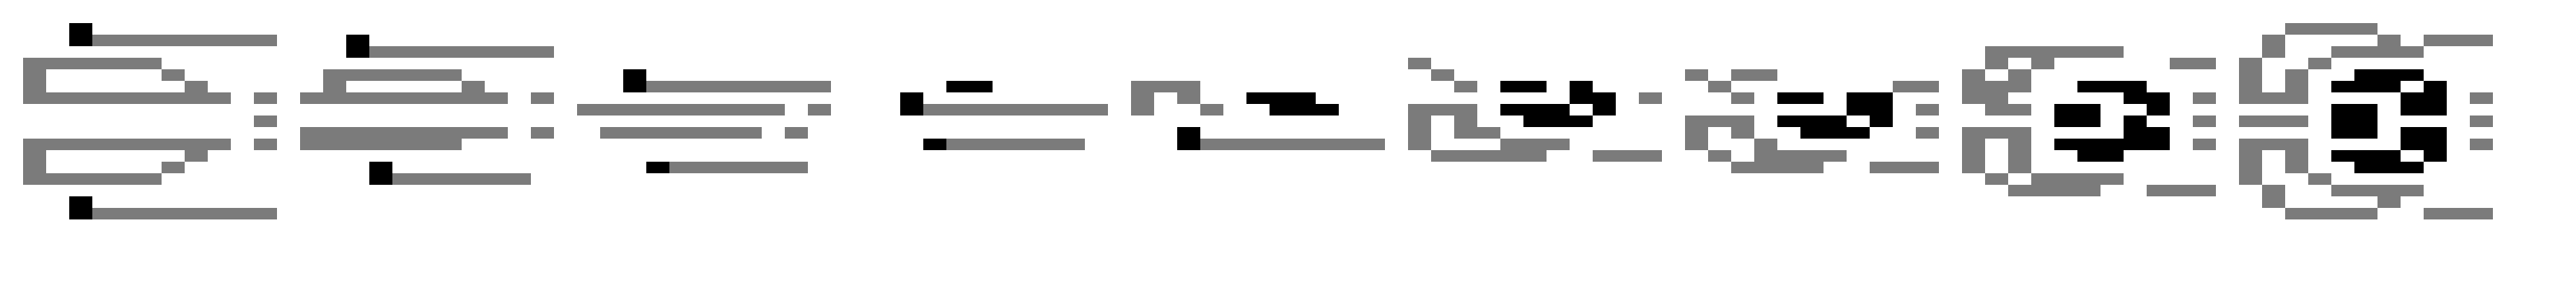

In [310]:
frames = list(reversed(animations["mantaFlipFromLeftToRight"]))[8:]
img = animateFrames(frames, level=6, offset=360)
img.save("manta_flip/manta_flip_2.png")
img

## Animation over a surface with shadow

In [118]:
from colors_map import *
raw_level_color_schemes = """
        .BYTE M_GRAY1,M_GRAY3,M_ORANGE,M_YELLOW,M_ORANGE  ; Level 1
        .BYTE M_BLACK,M_GRAY1,M_LTBLUE,M_LTRED,M_RED      ; Level 2, Level 13
        .BYTE M_BROWN,M_ORANGE,M_ORANGE,M_LTGREEN,M_GREEN ; Level 3, Level 11
        .BYTE M_GRAY1,M_GRAY3,M_ORANGE,M_LTBLUE,M_BLUE    ; Level 4
        .BYTE M_GREEN,M_LTGREEN,M_ORANGE,M_LTBLUE,M_BLUE  ; Level 5
        .BYTE M_ORANGE,M_YELLOW,M_ORANGE,M_GRAY2,M_BLACK  ; Level 6
        .BYTE M_GRAY1,M_CYAN,M_LTGREEN,M_LTRED,M_RED      ; Level 7
        .BYTE M_BLACK,M_GRAY2,M_LTRED,M_LTBLUE,M_BLUE     ; Level 8
        .BYTE M_BLUE,M_LTBLUE,M_ORANGE,M_LTGREEN,M_GREEN  ; Level 9 , Level 14
        .BYTE M_GRAY1,M_GRAY2,M_GRAY2,M_LTRED,M_RED       ; Level 10
        .BYTE M_BROWN,M_ORANGE,M_ORANGE,M_LTGREEN,M_GREEN ; Level 3, Level 11
        .BYTE M_BLUE,M_CYAN,M_ORANGE,M_GRAY2,M_GRAY1      ; Level 12
        .BYTE M_BLACK,M_GRAY1,M_LTBLUE,M_LTRED,M_RED      ; Level 2, Level 13
        .BYTE M_BLUE,M_LTBLUE,M_ORANGE,M_LTGREEN,M_GREEN  ; Level 9 , Level 14
        .BYTE M_RED,M_LTRED,M_ORANGE,M_YELLOW,M_ORANGE    ; Level 15
"""
raw_level_color_schemes = [l[14:57].split(',') for l in raw_level_color_schemes.split('\n')][1:-1]
raw_level_color_schemes = [[x.strip() for x in l] for l in raw_level_color_schemes]
#raw_level_color_schemes = [v for l in raw_level_color_schemes for v in l]
#surface_ram = [temp_surface_ram[v:v+80] for v in range(0, len(temp_surface_ram), 80)]
#surface_ram = ["$"+x.upper() for x in flatten(surface_ram)]
level_colors = [None]
for l in raw_level_color_schemes:
    colors = (color_constants[l[1]], "c64_black", color_constants[l[0]], "c64_white")
    level_colors += [colors]

# The character sets each level uses.
level_charsets = [0,2,0,2,0,1,2,1,0,1,2,0,2,1,0,2]

level_names = [None, "Zinc","Lead","Copper","Silver","Iron","Gold","Platinum","Tungsten",
               "Iridon","Kallisto","Tri-alloy","Quadmium","Ergonite","Galactium","Uridium"]

In [183]:
from PIL import Image

FACTOR = 15

def get_surface_snippet(level=1, x_offset=600, y_offset = 0, width=1000, height = 200):
    img = Image.open(f"surfaces_raw/{level}_full.png")
    img = img.resize((int(img.width * FACTOR), int(img.height * FACTOR)), Image.NEAREST)
    img = img.crop((x_offset, y_offset, x_offset + width, y_offset + height))
    return img

def make_shadow(img, color):
    color = ImageColor.getrgb(c64_to_rgb[color])
    d = img.getdata()
    new_image = []
    for item in d:
        if item[3] == 0:
            new_image.append(item)
        else:
            new_image.append(color)
    # update image data
    img.putdata(new_image)
    return img

resize = lambda img,factor: img.resize((int(img.width * factor), int(img.height * factor)), Image.NEAREST)
add_offset = lambda a,b : [sum(x) for x in zip(a,b)]
scale = lambda x: x * FACTOR
cells = lambda x: x * 120

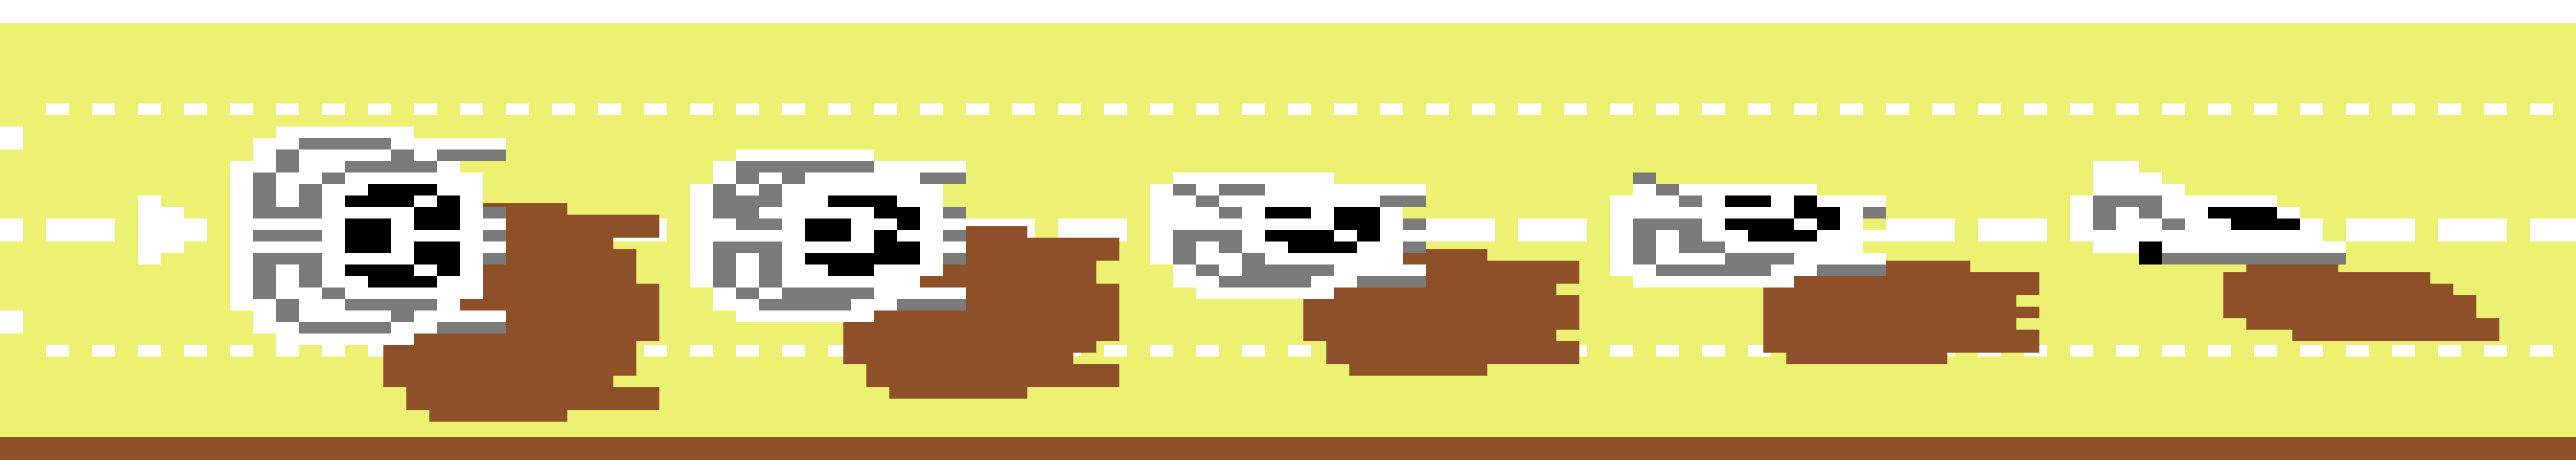

In [201]:
level = 6
diagram = get_surface_snippet(level=level, x_offset=scale(3324), y_offset = 240, width=scale(224), height = scale(40))

x = 20
offset = 40
animation = "bankLeftTo90DegreesFacingRight"
for sprite_name in reversed(animations[animation]): # The sprite animation starts at the end of the list.
    manta = Image.open(f"manta_sprites/{level}_{sprite_name}.png")
    manta = resize(manta, FACTOR)
    shadow = manta.copy()
    shadow = make_shadow(shadow, color=level_colors[level][2])

    manta_pos = (scale(x),scale(10))
    shadow_offset = (20*10,10*10)
    diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
    diagram.paste(manta, manta_pos, mask=manta)
    x+=offset
diagram

In [369]:
shadow_offsets_for_turn = [-x for x in [0,0,-1,-2,-3,-3,-2,-2,-1,0,1,2,3,3,2,2,1,0]]

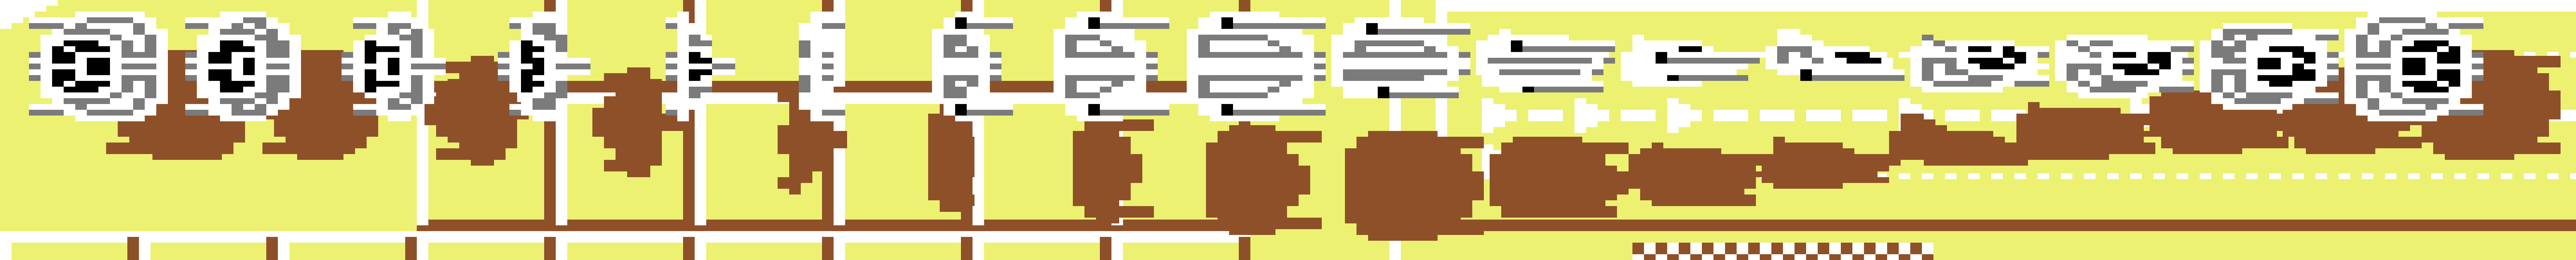

In [394]:
level = 6
diagram = get_surface_snippet(level=level, x_offset=scale(3064), y_offset = 240, width=scale(445), height = scale(45))

x = 5
offset = 25
animation = "mantaFlipFromLeftToRight"
start_sprite = "MANTA1"
base_shadow_offset = (20*10,10*10)
shadow_offset = base_shadow_offset
for i, sprite_name in enumerate(reversed(animations[animation])): 
    manta = Image.open(f"manta_sprites/{level}_{sprite_name}.png")
    manta = resize(manta, FACTOR)
    shadow = manta.copy()
    shadow = make_shadow(shadow, color=level_colors[level][2])

    manta_pos = (scale(x),scale(1))
    frame_offset = (scale(shadow_offsets_for_turn[i]), scale(shadow_offsets_for_turn[i]))
    shadow_offset = add_offset(shadow_offset, frame_offset)
    diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
    diagram.paste(manta, manta_pos, mask=manta)
    x+=offset
diagram.save("manta_flip/flip_diagram.png")
diagram

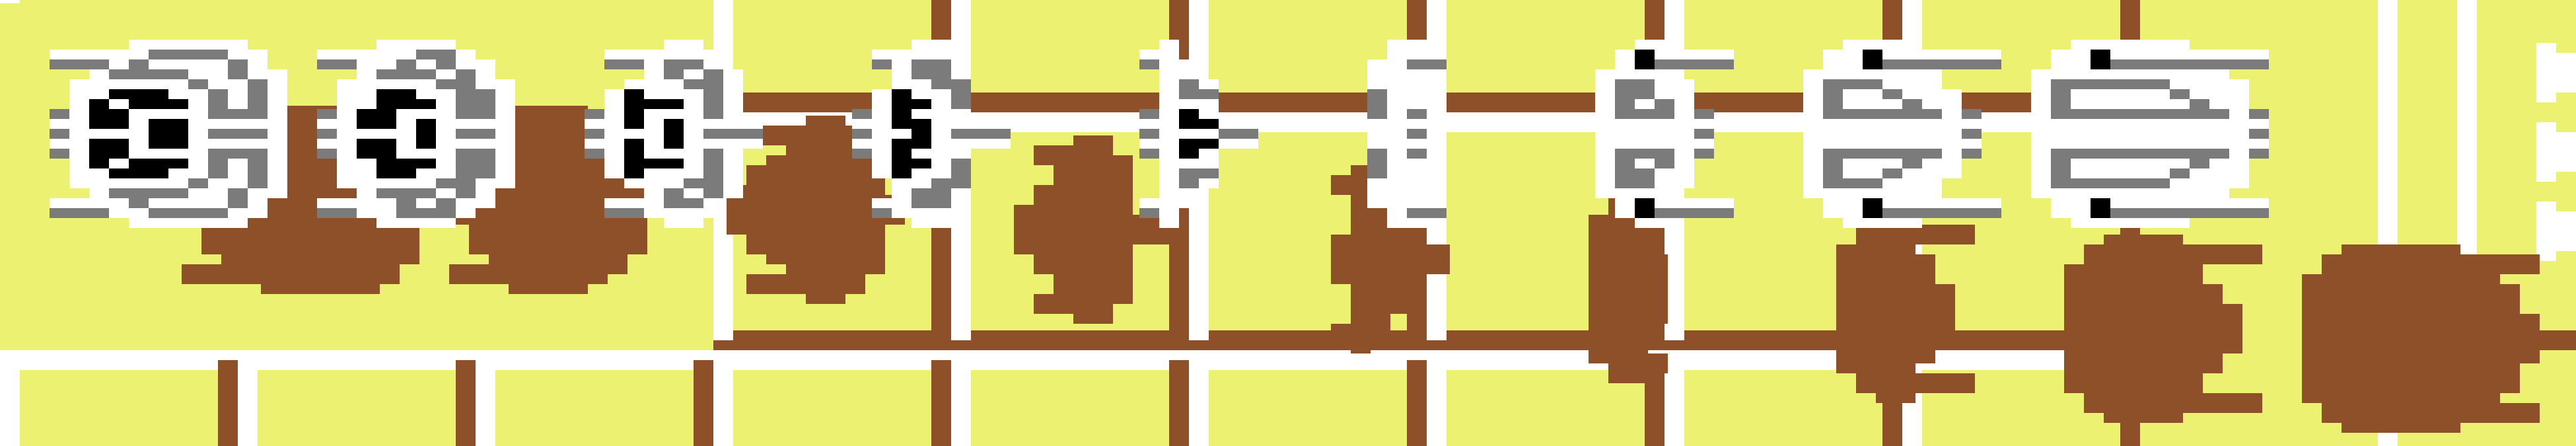

In [398]:
level = 6
diagram = get_surface_snippet(level=level, x_offset=scale(3064), y_offset = 310, width=scale(260), height = scale(45))

x = 5
offset = 25
animation = "mantaFlipFromLeftToRight"
start_sprite = "MANTA1"
base_shadow_offset = (20*10,10*10)
shadow_offset = base_shadow_offset

frames = list(reversed(animations[animation]))[:9]
for i, sprite_name in enumerate(frames): 
    manta = Image.open(f"manta_sprites/{level}_{sprite_name}.png")
    manta = resize(manta, FACTOR)
    shadow = manta.copy()
    shadow = make_shadow(shadow, color=level_colors[level][2])

    manta_pos = (scale(x),scale(3))
    frame_offset = (scale(shadow_offsets_for_turn[i]), scale(shadow_offsets_for_turn[i]))
    shadow_offset = add_offset(shadow_offset, frame_offset)
    diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
    diagram.paste(manta, manta_pos, mask=manta)
    x+=offset
diagram.save("manta_flip/flip_diagram_1.png")
diagram

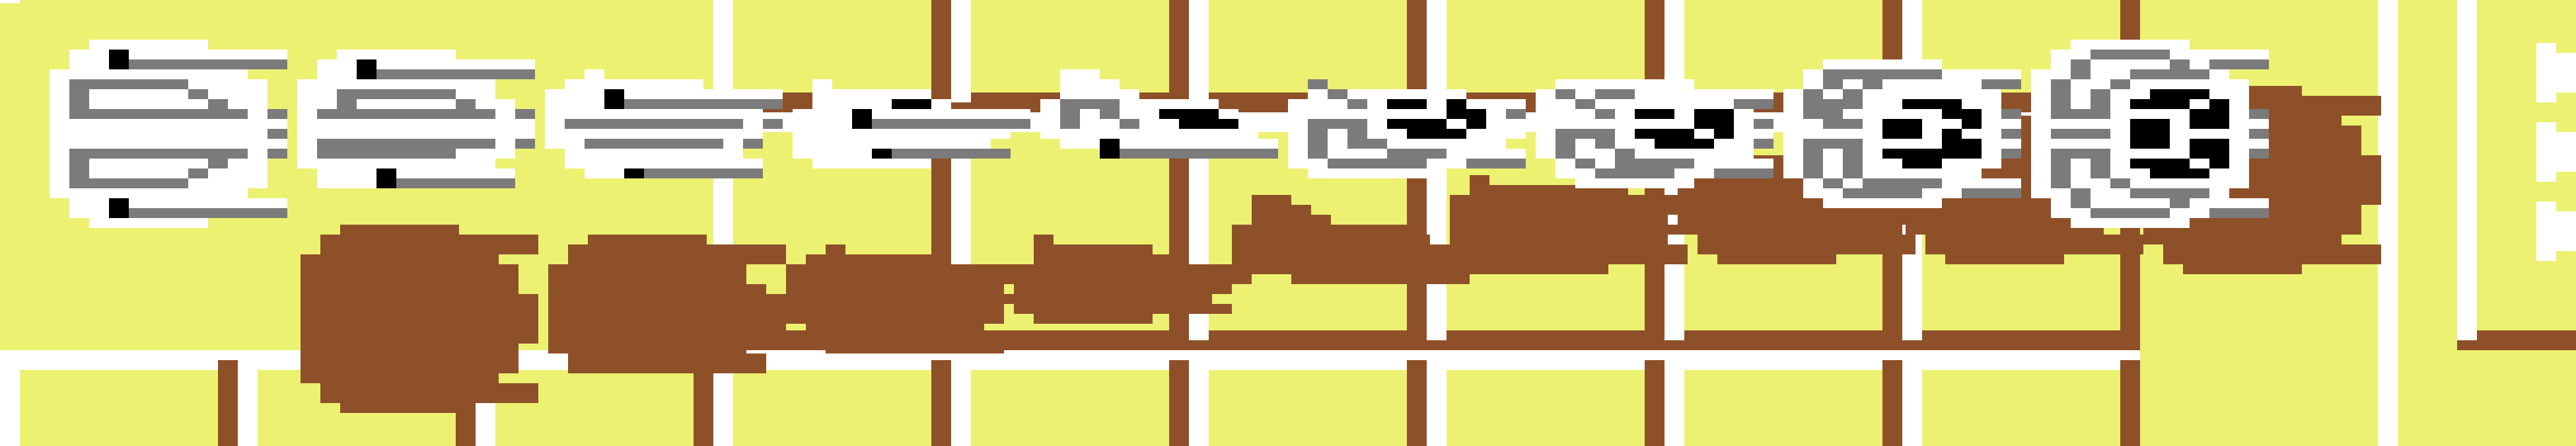

In [409]:
level = 6
diagram = get_surface_snippet(level=level, x_offset=scale(3064), y_offset = 310, width=scale(260), height = scale(45))

x = 5
offset = 25
animation = "mantaFlipFromLeftToRight"
start_sprite = "MANTA1"
base_shadow_offset = (20*10,10*10)
shadow_offset = base_shadow_offset

shadow_offsets_for_roll = [-x for x in [-12,0,1,2,3,3,2,2,1,0]]

frames = list(reversed(animations[animation]))[8:]
for i, sprite_name in enumerate(frames): 
    manta = Image.open(f"manta_sprites/{level}_{sprite_name}.png")
    manta = resize(manta, FACTOR)
    shadow = manta.copy()
    shadow = make_shadow(shadow, color=level_colors[level][2])

    manta_pos = (scale(x),scale(3))
    frame_offset = (scale(shadow_offsets_for_roll[i]), scale(shadow_offsets_for_roll[i]))
    shadow_offset = add_offset(shadow_offset, frame_offset)
    diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
    diagram.paste(manta, manta_pos, mask=manta)
    x+=offset
diagram.save("manta_flip/flip_diagram_2.png")
diagram

### Do the animation without offsetting the shadow properly

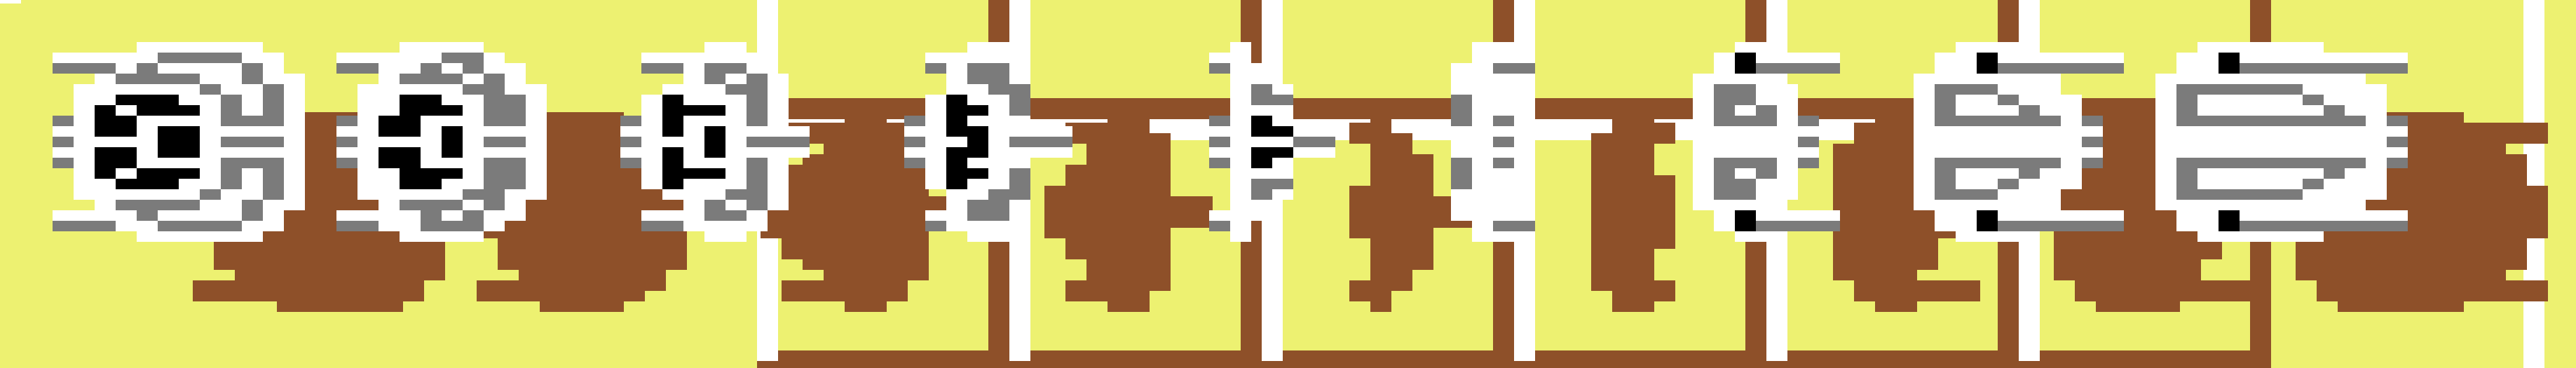

In [383]:
level = 6
diagram = get_surface_snippet(level=level, x_offset=scale(3064), y_offset = 310, width=scale(245), height = scale(35))

x = 5
offset = 25
animation = "mantaFlipFromLeftToRight"
start_sprite = "MANTA1"
base_shadow_offset = (20*10,10*10)

frames = list(reversed(animations[animation]))[:9]
for i, sprite_name in enumerate(frames): 
    manta = Image.open(f"manta_sprites/{level}_{sprite_name}.png")
    manta = resize(manta, FACTOR)
    shadow = manta.copy()
    shadow = make_shadow(shadow, color=level_colors[level][2])

    manta_pos = (scale(x),scale(3))
    frame_offset = (scale(shadow_offsets_for_turn[i]), scale(shadow_offsets_for_turn[i]))
    #shadow_offset = add_offset(base_shadow_offset, frame_offset)
    diagram.paste(shadow, add_offset(manta_pos, base_shadow_offset), mask=shadow)
    diagram.paste(manta, manta_pos, mask=manta)
    x+=offset
diagram.save("manta_flip/flip_diagram_1_no_offset.png")
diagram

## Maneuver Diagrams

In [188]:
manta_sprite_refs = {
    "MANTA":"$40",
    "MANTA1":"$41",
    "MANTA_2":"$42",
    "MANTA_RIGHT_3":"$43",
    "MANTA_RIGHT_4":"$44",
    "MANTA_RIGHT_5":"$45",
    "MANTA_RIGHT_6":"$46",
    "MANTA_RIGHT_7":"$47",
    "MANTA_RIGHT_8":"$48",
    "MANTA_RIGHT_9":"$49",
    "MANTA_RIGHT_10":"$4A",
    "MANTA_RIGHT_11":"$4B",
    "MANTA_RIGHT_12":"$4C",
    "MANTA_RIGHT_13":"$4D",
    "MANTA_RIGHT_14":"$4E",
    "MANTA_RIGHT_15":"$4F",
    "MANTA_LEFT_0":"$50",
    "MANTA_LEFT_1":"$51",
    "MANTA_LEFT_2":"$52",
    "MANTA_LEFT_3":"$53",
    "MANTA_LEFT_4":"$54",
    "MANTA_LEFT_5":"$55",
    "MANTA_LEFT_6":"$56",
    "MANTA_LEFT_7":"$57",
    "MANTA_LEFT_8":"$58",
    "MANTA_LEFT_9":"$59",
    "MANTA_LEFT_10":"$5A",
    "MANTA_LEFT_11":"$5B",
    "MANTA_LEFT_12":"$5C",
    "MANTA_LEFT_13":"$5D",
    "MANTA_LEFT_14":"$5E",
    "MANTA_LEFT_15":"$5F",
    "MANTA_FLIP_0":"$60",
    "MANTA_FLIP_1":"$61",
    "MANTA_FLIP_2":"$62",
    "MANTA_FLIP_3":"$63",
    "MANTA_FLIP_4":"$64",
    "MANTA_FLIP_5":"$65",
    "MANTA_FLIP_6":"$66",
    "MANTA_FLIP_7":"$67",
    "MANTA_FLIP_8":"$68",
    "MANTA_FLIP_9":"$69",
    "MANTA_FLIP_10":"$6A",
    "MANTA_FLIP_11":"$6B",
    "MANTA_FLIP_12":"$6C",
    "MANTA_FLIP_13":"$6D",
    }

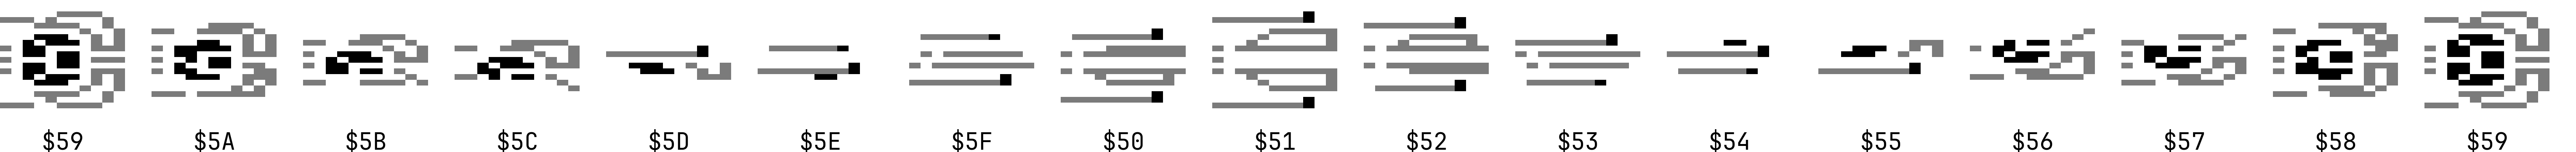

In [244]:
from PIL import Image, ImageDraw, ImageFont

level = 6

for animation_name in animations:
    frames = animations[animation_name]
    img = Image.new('RGBA', (len(frames) * 400, 400))
    draw = ImageDraw.Draw(img)
    x,y = 0,0
    for sprite_name in reversed(frames):
        manta = Image.open(f"manta_sprites/{level}_{sprite_name}.png")
        manta = resize(manta, FACTOR)
        img.paste(manta, (x,y))

        label_text = manta_sprite_refs[sprite_name]
        label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", 62)
        label_x = x + 110
        label_y = y + 330
        draw.text((label_x, label_y), label_text, font=label_fnt, fill="black")
        
        x+= 400
    img.save(f"animations/{level}_{animation_name}.png")
img

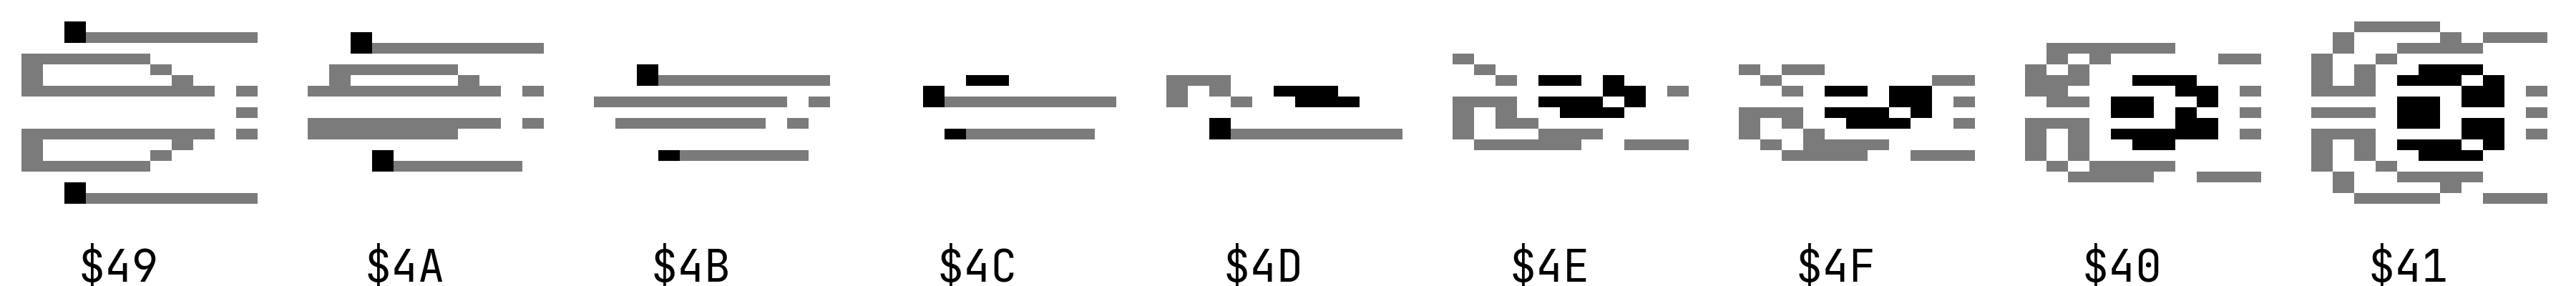

In [320]:
from PIL import Image, ImageDraw, ImageFont

level = 6
animation_name = "mantaFlipFromLeftToRight"

for i in range(0,16,8):
    frames = list(reversed(animations[animation_name]))[i:i+9]
    img = Image.new('RGBA', (len(frames) * 400, 400))
    draw = ImageDraw.Draw(img)
    x,y = 0,0
    for sprite_name in frames:
        manta = Image.open(f"manta_sprites/{level}_{sprite_name}.png")
        manta = resize(manta, FACTOR)
        img.paste(manta, (x,y))

        label_text = manta_sprite_refs[sprite_name]
        label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", 62)
        label_x = x + 110
        label_y = y + 330
        draw.text((label_x, label_y), label_text, font=label_fnt, fill="black")

        x+= 400
    img.save(f"manta_flip/{level}_{animation_name}_{i}.png")
img

In [322]:
level = 6
animation_name = "mantaFlipFromLeftToRight"
','.join([manta_sprite_refs[x] for x in animations[animation_name]])

'$41,$40,$4F,$4E,$4D,$4C,$4B,$4A,$49,$67,$68,$69,$6A,$6B,$6C,$6D,$59'

### Save copies of the sprites using their hex references

In [413]:
from PIL import Image, ImageDraw, ImageFont

level = 6
for level in range (1,16):
    for animation_name in animations:
        frames = animations[animation_name]
        for sprite_name in frames:
            manta = Image.open(f"manta_sprites/{level}_{sprite_name}.png")
            label_text = manta_sprite_refs[sprite_name][1:]
            manta.save(f"manta_sprites/{level}_{label_text}.png")


### Illustrate the manta dimension hints

In [428]:
dimension_hints = """
        .BYTE $80,$80,$80,$80,$00,$00,$00,$80
        .BYTE $80,$80,$80,$80,$00,$00,$00,$80
        .BYTE $80,$80,$80,$80,$00,$00,$00,$80
        .BYTE $80,$80,$80,$80,$00,$00,$00,$80
        .BYTE $80,$80,$81,$81,$81,$80,$80,$80
        .BYTE $80,$81,$81,$81,$80,$80,$00    
""".split('\n')[1:-1]
dimension_hints = [c for l in dimension_hints for c in l[14:].strip().split(',')]

In [431]:
mkdir -p manta_flip/dimension_hints

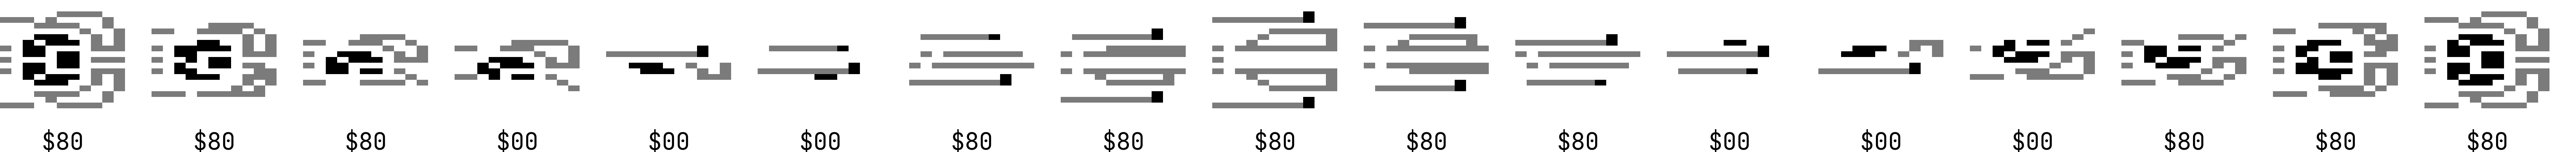

In [433]:
from PIL import Image, ImageDraw, ImageFont

level = 6

for animation_name in animations:
    frames = list(reversed(animations[animation_name]))
    img = Image.new('RGBA', (len(frames) * 400, 400))
    draw = ImageDraw.Draw(img)
    x,y = 0,0
    for sprite_name in frames:
        manta = Image.open(f"manta_sprites/{level}_{sprite_name}.png")
        manta = resize(manta, FACTOR)
        img.paste(manta, (x,y))

        dimension_hint_index = int(manta_sprite_refs[sprite_name][1:],16) - 0x40
        label_text = dimension_hints[dimension_hint_index]
        label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", 62)
        label_x = x + 110
        label_y = y + 330
        draw.text((label_x, label_y), label_text, font=label_fnt, fill="black")

        x+= 400
    img.save(f"manta_flip/dimension_hints/{level}_{animation_name}_dimension_hints.png")
img

# Scratchpad

In [410]:
hex(0x33e8 + 0x40)

'0x3428'